---

# COVID-19 Data Analysis

---




# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style for charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# Load Datasets

In [2]:
country = pd.read_csv("country_wise_latest.csv")
clean = pd.read_csv("covid_19_clean_complete.csv")
day = pd.read_csv("day_wise.csv")
usa = pd.read_csv("usa_county_wise.csv")

In [3]:
print(country.head())
print(day.head())

  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737   
1   

# Check Missing Values

In [4]:
print(country.isnull().sum())
print(clean.isnull().sum())

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


In [5]:
# Country Dataset Info
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

# Top 10 Countries by Confirmed Cases

---



/tmp/ipykernel_32295/2851954637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Confirmed", y="Country/Region", data=top_cases, palette="Reds_r")


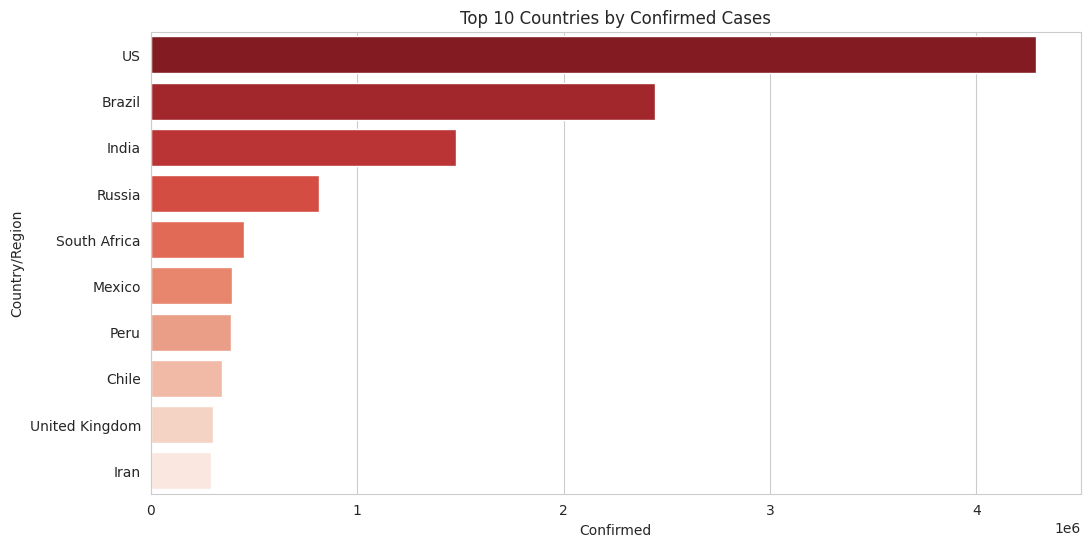

In [6]:
top_cases = country.sort_values("Confirmed", ascending=False).head(10)

sns.barplot(x="Confirmed", y="Country/Region", data=top_cases, palette="Reds_r")
plt.title("Top 10 Countries by Confirmed Cases")
plt.show()

# Top 10 Countries by Deaths

---



/tmp/ipykernel_32295/3430907880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Deaths", y="Country/Region", data=top_deaths, palette="Blues_r")


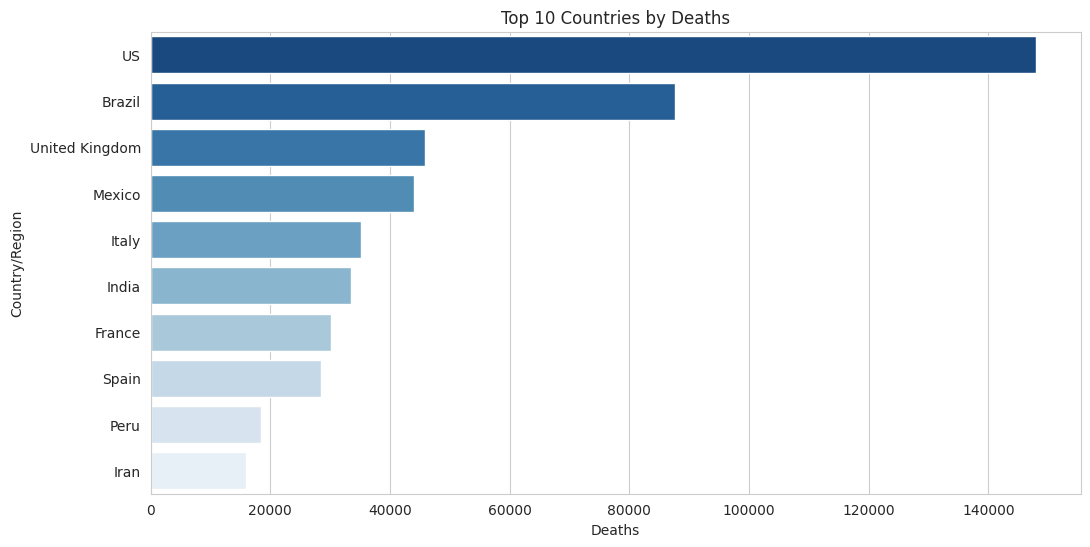

In [7]:
top_deaths = country.sort_values("Deaths", ascending=False).head(10)

sns.barplot(x="Deaths", y="Country/Region", data=top_deaths, palette="Blues_r")
plt.title("Top 10 Countries by Deaths")
plt.show()

# Recovery Rate

---



/tmp/ipykernel_32295/1081995654.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Recovery Rate", y="Country/Region", data=top_recovery, palette="Greens_r")


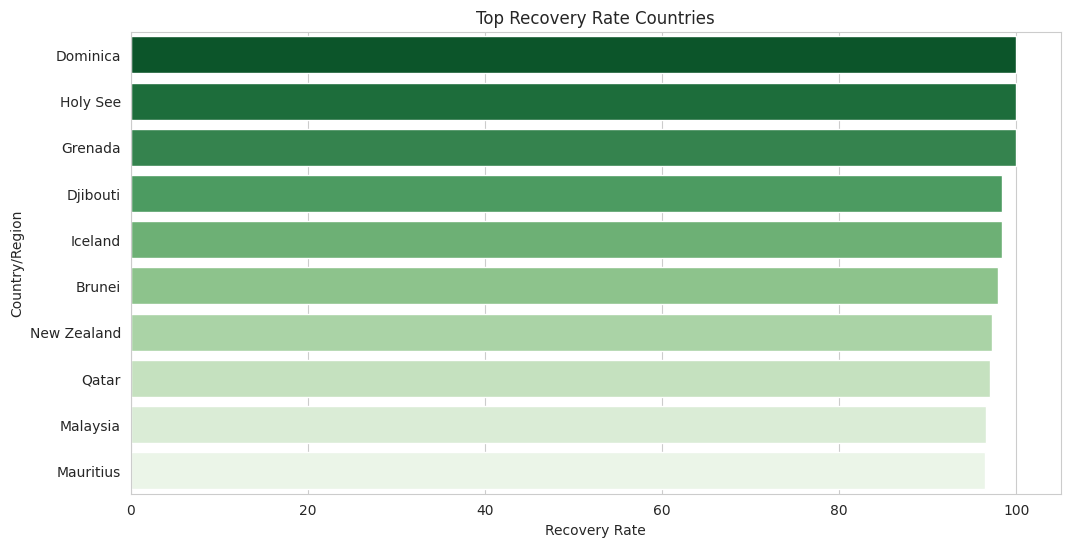

In [8]:
country["Recovery Rate"] = (country["Recovered"] / country["Confirmed"]) * 100

top_recovery = country.sort_values("Recovery Rate", ascending=False).head(10)

sns.barplot(x="Recovery Rate", y="Country/Region", data=top_recovery, palette="Greens_r")
plt.title("Top Recovery Rate Countries")
plt.show()

# Death Rate

---



/tmp/ipykernel_32295/3689673842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Death Rate", y="Country/Region", data=top_deathrate, palette="Purples_r")


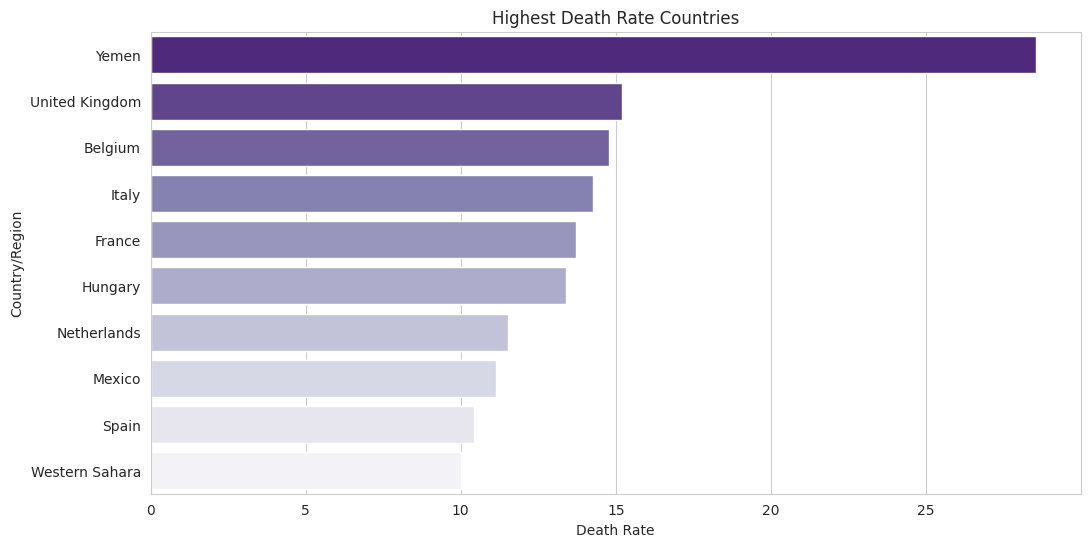

In [9]:
country["Death Rate"] = (country["Deaths"] / country["Confirmed"]) * 100

top_deathrate = country.sort_values("Death Rate", ascending=False).head(10)

sns.barplot(x="Death Rate", y="Country/Region", data=top_deathrate, palette="Purples_r")
plt.title("Highest Death Rate Countries")
plt.show()

# Global Daily Cases Trend

---



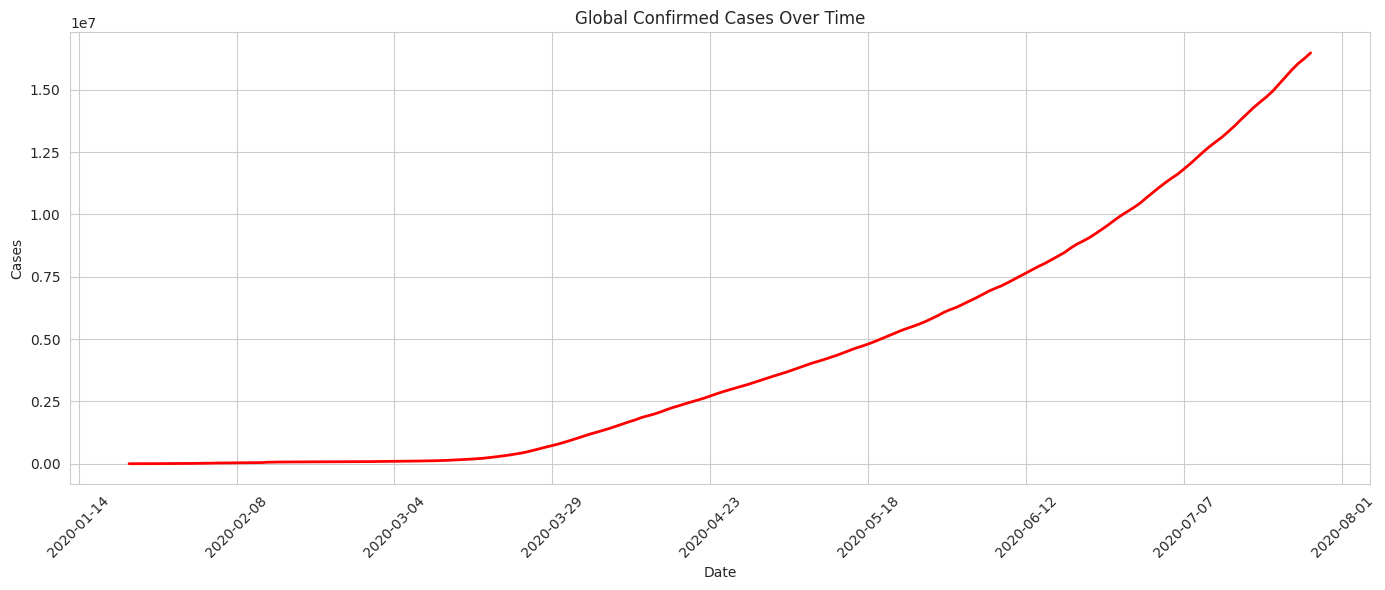

In [11]:
# Convert Date column to datetime
day["Date"] = pd.to_datetime(day["Date"])

# Plot with better date formatting
plt.figure(figsize=(14,6))
plt.plot(day["Date"], day["Confirmed"], color="red", linewidth=2)

# Show fewer dates on x-axis
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

plt.title("Global Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.tight_layout()
plt.show()

# Daily Death Trend

---



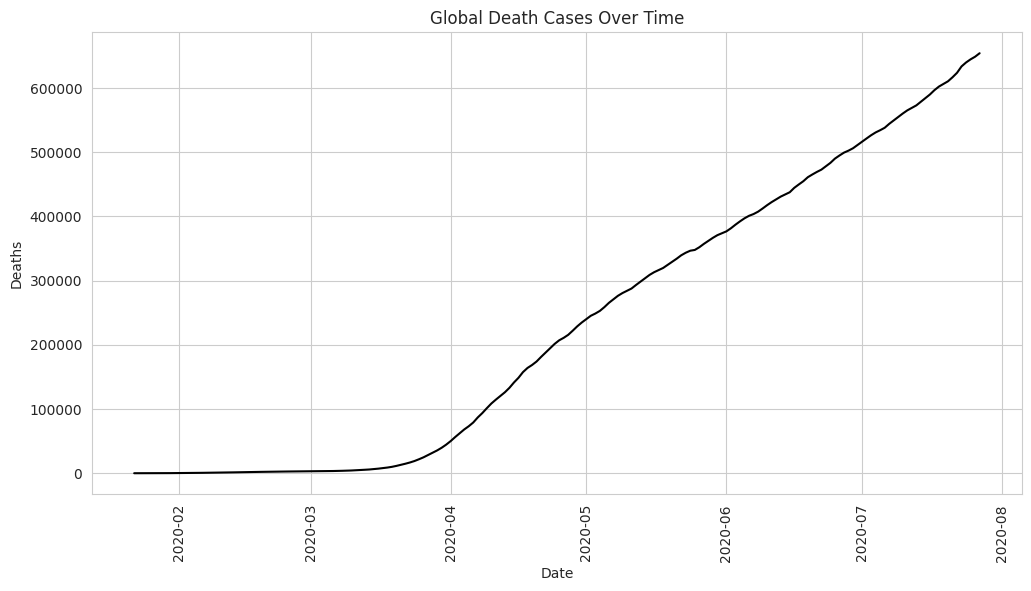

In [12]:
plt.plot(day["Date"], day["Deaths"], color="black")
plt.xticks(rotation=90)
plt.title("Global Death Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()

# India vs USA vs Brazil Comparison

---



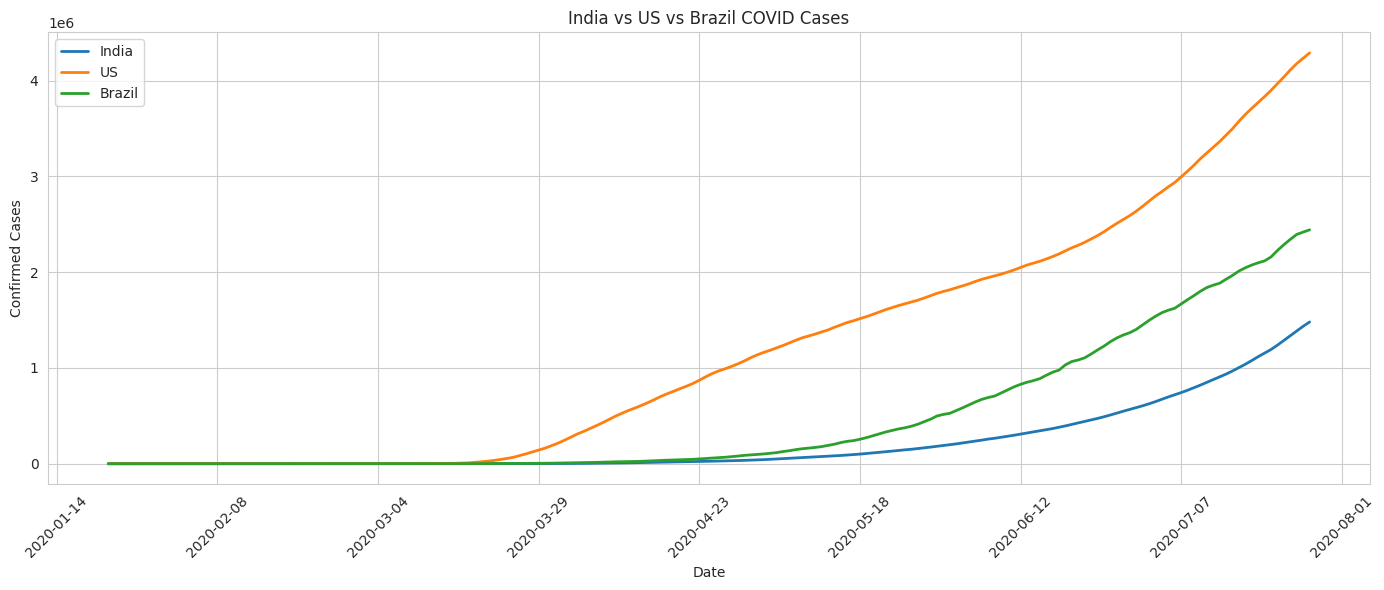

In [14]:
# Convert Date column to datetime
clean["Date"] = pd.to_datetime(clean["Date"])

# Filter selected countries
selected = clean[clean["Country/Region"].isin(["India", "US", "Brazil"])]

# Plot
plt.figure(figsize=(14,6))

for c in ["India", "US", "Brazil"]:
    temp = selected[selected["Country/Region"] == c]
    plt.plot(temp["Date"], temp["Confirmed"], linewidth=2, label=c)

# Better date formatting
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

plt.title("India vs US vs Brazil COVID Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation Heatmap

---



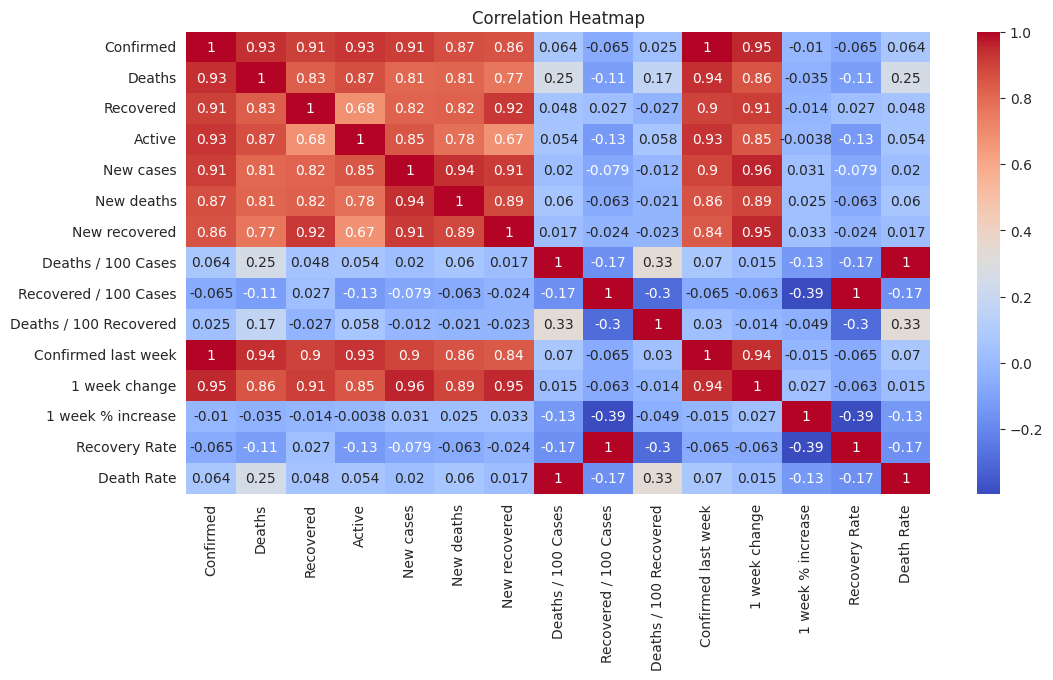

In [15]:
sns.heatmap(country.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Final Insights Print

---



In [19]:
print("Top Country by Cases:", country.sort_values("Confirmed", ascending=False).iloc[0]["Country/Region"])
print("Top Country by Deaths:", country.sort_values("Deaths", ascending=False).iloc[0]["Country/Region"])
print("Highest Recovery Rate:", country.sort_values("Recovery Rate", ascending=False).iloc[0]["Country/Region"])

Top Country by Cases: US
Top Country by Deaths: US
Highest Recovery Rate: Dominica
